# Laboratorio 3 – Modelos de Regresión Lineal
## CC3074 – Minería de Datos | Semestre I – 2026
### InmoValor S.A. – Predicción de precios de viviendas

**Dataset:** House Prices: Advanced Regression Techniques (Kaggle)

**Objetivo:** Desarrollar modelos de regresión lineal para predecir el precio de venta (`SalePrice`) de viviendas en Ames, Iowa, a partir de 79 variables explicativas que describen aspectos como calidad, tamaño, ubicación y condición de las propiedades.

---

## 1. Importación de Librerías y Carga de Datos

In [1]:
%pip install -q pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, skew, kurtosis

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 85)
pd.set_option('display.max_rows', 100)
import warnings
warnings.filterwarnings('ignore')

print("Librerias importadas correctamente")

Librerias importadas correctamente


In [3]:
# Carga de datos
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Dataset de entrenamiento: {train.shape[0]} filas x {train.shape[1]} columnas")
print(f"Dataset de prueba: {test.shape[0]} filas x {test.shape[1]} columnas")
print(f"\nVariable objetivo: SalePrice")
print(f"   - Presente en train: {'SalePrice' in train.columns}")
print(f"   - Presente en test: {'SalePrice' in test.columns}")

Dataset de entrenamiento: 1460 filas x 81 columnas
Dataset de prueba: 1459 filas x 80 columnas

Variable objetivo: SalePrice
   - Presente en train: True
   - Presente en test: False


## 2. Descripción de las Variables

El dataset contiene **81 variables** (incluyendo `Id` y `SalePrice`). Las variables se pueden categorizar en los siguientes grupos temáticos:

| Categoría | Variables | Descripción |
|---|---|---|
| **Identificación** | `Id` | Identificador único de la propiedad |
| **Tipo de vivienda** | `MSSubClass`, `BldgType`, `HouseStyle` | Clasificación del tipo de construcción y estilo |
| **Zonificación y terreno** | `MSZoning`, `LotFrontage`, `LotArea`, `LotShape`, `LandContour`, `LotConfig`, `LandSlope` | Características del terreno y zonificación |
| **Acceso e infraestructura** | `Street`, `Alley`, `Utilities`, `PavedDrive` | Tipo de acceso y servicios disponibles |
| **Ubicación** | `Neighborhood`, `Condition1`, `Condition2` | Vecindario y proximidad a características |
| **Calidad general** | `OverallQual`, `OverallCond` | Calificación general de calidad y condición (1-10) |
| **Antigüedad** | `YearBuilt`, `YearRemodAdd` | Año de construcción y remodelación |
| **Techo** | `RoofStyle`, `RoofMatl` | Estilo y material del techo |
| **Exterior** | `Exterior1st`, `Exterior2nd`, `MasVnrType`, `MasVnrArea`, `ExterQual`, `ExterCond` | Materiales y calidad exterior |
| **Cimentación y sótano** | `Foundation`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinSF1`, `BsmtFinType2`, `BsmtFinSF2`, `BsmtUnfSF`, `TotalBsmtSF` | Características del sótano |
| **Calefacción y aire** | `Heating`, `HeatingQC`, `CentralAir` | Sistema de calefacción y aire acondicionado |
| **Eléctrico** | `Electrical` | Sistema eléctrico |
| **Superficie habitable** | `1stFlrSF`, `2ndFlrSF`, `LowQualFinSF`, `GrLivArea` | Pies cuadrados por nivel |
| **Baños** | `BsmtFullBath`, `BsmtHalfBath`, `FullBath`, `HalfBath` | Cantidad de baños |
| **Habitaciones** | `BedroomAbvGr`, `KitchenAbvGr`, `KitchenQual`, `TotRmsAbvGrd` | Habitaciones sobre nivel |
| **Funcionalidad** | `Functional` | Funcionalidad de la vivienda |
| **Chimenea** | `Fireplaces`, `FireplaceQu` | Número y calidad de chimeneas |
| **Garaje** | `GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageCars`, `GarageArea`, `GarageQual`, `GarageCond` | Características del garaje |
| **Áreas exteriores** | `WoodDeckSF`, `OpenPorchSF`, `EnclosedPorch`, `3SsnPorch`, `ScreenPorch` | Porches y áreas exteriores |
| **Piscina** | `PoolArea`, `PoolQC` | Área y calidad de piscina |
| **Otros** | `Fence`, `MiscFeature`, `MiscVal` | Cerca, características misceláneas |
| **Venta** | `MoSold`, `YrSold`, `SaleType`, `SaleCondition` | Información de la venta |
| **Variable objetivo** | `SalePrice` | **Precio de venta de la vivienda (USD)** |

In [4]:
# Vista general del dataset
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET DE ENTRENAMIENTO")
print("=" * 80)
print(f"\nDimensiones: {train.shape}")
print(f"\nPrimeras 5 filas:")
train.head()

INFORMACIÓN GENERAL DEL DATASET DE ENTRENAMIENTO

Dimensiones: (1460, 81)

Primeras 5 filas:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Clasificacion de variables por tipo de dato
numeric_columns = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = train.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numericas ({len(numeric_columns)}):")
print(f"   {numeric_columns}\n")
print(f"Variables categoricas ({len(categorical_columns)}):")
print(f"   {categorical_columns}\n")

# Informacion detallada de tipos de datos
print("=" * 80)
print("TIPOS DE DATOS Y VALORES NO NULOS")
print("=" * 80)
train.info()

Variables numericas (38):
   ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Variables categoricas (43):
   ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Fu

In [6]:
# Estadisticas descriptivas de variables numericas
print("=" * 80)
print("ESTADISTICAS DESCRIPTIVAS - VARIABLES NUMERICAS")
print("=" * 80)
train[numeric_columns].describe().T.round(2)

ESTADISTICAS DESCRIPTIVAS - VARIABLES NUMERICAS


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.50,421.61,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.90,42.30,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.05,24.28,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.83,9981.26,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.10,1.38,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.58,1.11,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.27,30.20,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.87,20.65,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.69,181.07,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.64,456.10,0.0,0.00,383.5,712.25,5644.0


### 2.1 Análisis de Valores Faltantes

Un paso crucial en la exploración es identificar qué variables tienen datos faltantes, cuántos y por qué. En este dataset, muchos valores `NaN` en realidad significan "no aplica" (por ejemplo, `PoolQC = NaN` significa que no hay piscina).

Variables con valores faltantes: 19 de 81
Variables sin valores faltantes: 62



,Valores Faltantes,Porcentaje (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


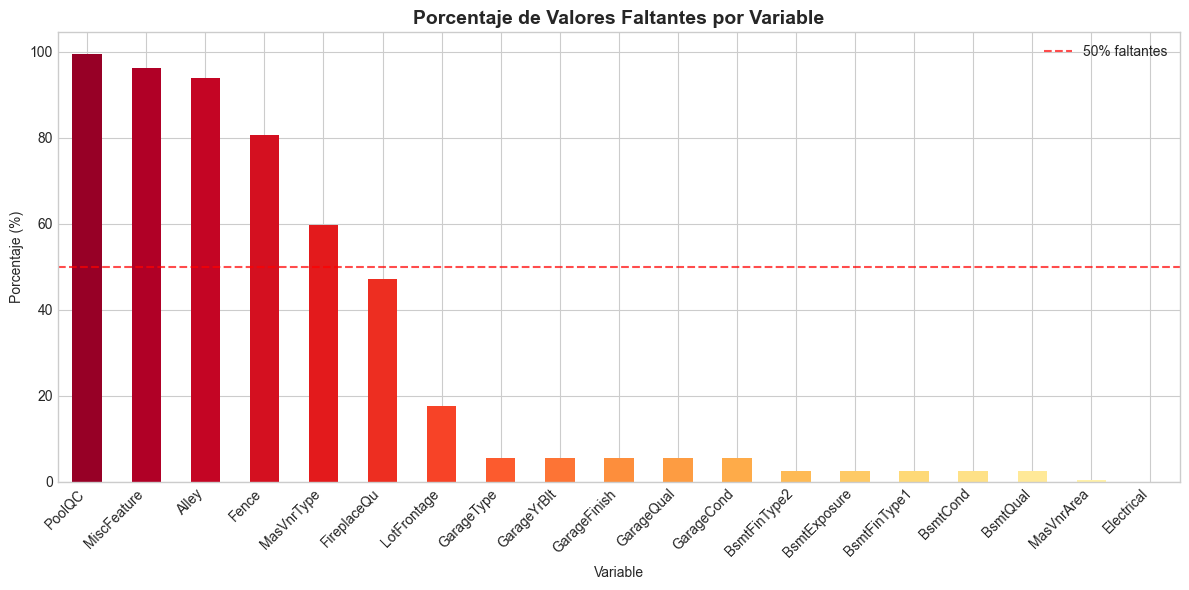

In [7]:
# Analisis de valores faltantes
null_counts = train.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
null_percentage = (null_counts / len(train) * 100).round(2)

missing_summary = pd.DataFrame({
    'Valores Faltantes': null_counts,
    'Porcentaje (%)': null_percentage
})

total_columns = train.shape[1]
columns_with_nulls = len(missing_summary)

print(f"Variables con valores faltantes: {columns_with_nulls} de {total_columns}")
print(f"Variables sin valores faltantes: {total_columns - columns_with_nulls}\n")
display(missing_summary)

# Visualizacion de valores faltantes
fig, ax = plt.subplots(figsize=(12, 6))
null_percentage.plot(kind='bar', color=sns.color_palette("YlOrRd_r", len(null_percentage)), ax=ax)
ax.set_title('Porcentaje de Valores Faltantes por Variable', fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje (%)')
ax.set_xlabel('Variable')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% faltantes')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Hallazgos sobre valores faltantes:**

- **PoolQC (99.5%), MiscFeature (96.3%), Alley (93.8%), Fence (80.8%):** Estos altos porcentajes no son realmente "datos perdidos". Significan que la mayoría de casas no tienen piscina, característica miscelánea, acceso por callejón, o cerca. Son informativos y se codificarán como "None".
- **FireplaceQu (47.3%):** Casas sin chimenea. Se codificará como "None".
- **Variables de garaje (~5.5%):** `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `GarageYrBlt` — casas sin garaje.
- **Variables de sótano (~2.5%):** `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` — casas sin sótano.
- **LotFrontage (17.7%):** Este sí es un dato faltante real. Se imputará con la mediana del vecindario.
- **MasVnrType y MasVnrArea (~0.5%):** Pocas observaciones, se imputarán.
- **Electrical (0.07%):** Un solo valor faltante, se imputará con la moda.

## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Distribución de la Variable Objetivo: `SalePrice`

**Pregunta:** ¿Cómo se distribuye el precio de venta? ¿Es simétrica o sesgada? ¿Hay outliers?

Comprender la distribución de `SalePrice` es fundamental ya que la regresión lineal asume normalidad en los residuos. Una variable objetivo muy sesgada puede afectar el rendimiento del modelo.

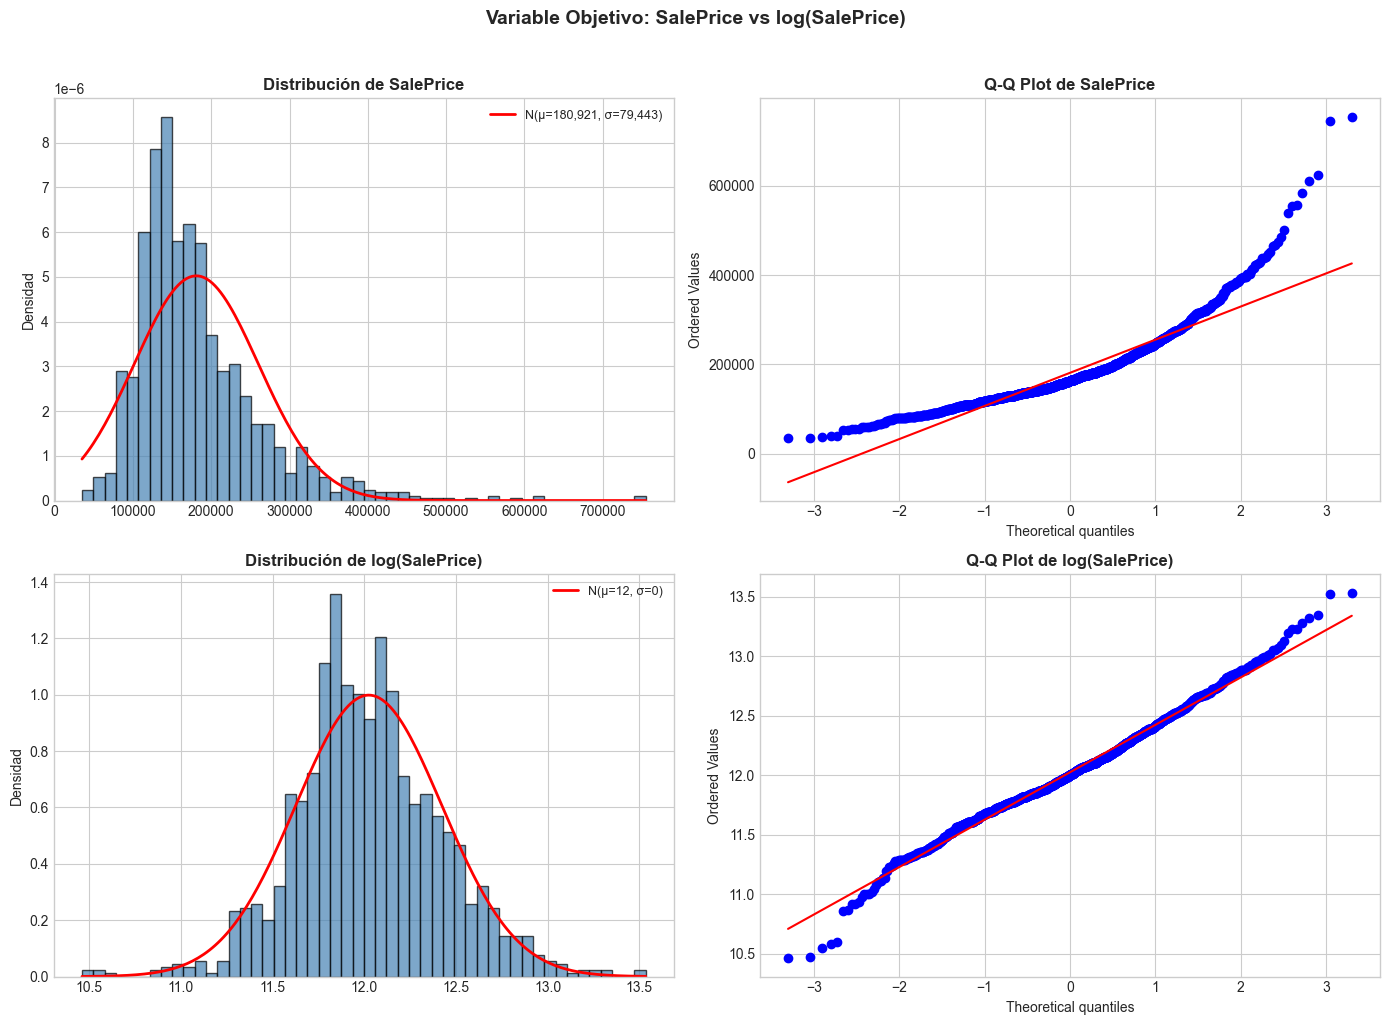

Estadística                SalePrice  log(SalePrice)
Media                     180,921.20         12.0241
Mediana                   163,000.00         12.0015
Desv. Est.                 79,415.29          0.3993
Skewness                      1.8809          0.1212
Kurtosis                      6.5098          0.8026

Shapiro-Wilk (SalePrice): W=0.829041, p=0.000000 → No normal (α=0.05)

Shapiro-Wilk (log(SalePrice)): W=0.986063, p=0.000102 → No normal (α=0.05)


In [8]:
def plot_distribution_analysis(series, title, axes_row):
    """Genera histograma + curva normal y Q-Q plot para una serie."""
    mu, sigma = series.mean(), series.std()

    # Histograma con curva normal superpuesta
    axes_row[0].hist(series, bins=50, density=True, alpha=0.7, 
                        color='steelblue', edgecolor='black')
    x = np.linspace(series.min(), series.max(), 200)
    axes_row[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2,
                        label=f'N(μ={mu:,.0f}, σ={sigma:,.0f})')
    axes_row[0].set_title(f'Distribución de {title}', fontweight='bold')
    axes_row[0].set_ylabel('Densidad')
    axes_row[0].legend(fontsize=9)

    # Q-Q plot
    stats.probplot(series, plot=axes_row[1])
    axes_row[1].set_title(f'Q-Q Plot de {title}', fontweight='bold')


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_distribution_analysis(train['SalePrice'], 'SalePrice', axes[0])
plot_distribution_analysis(np.log1p(train['SalePrice']), 'log(SalePrice)', axes[1])

plt.suptitle('Variable Objetivo: SalePrice vs log(SalePrice)',
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Estadísticas descriptivas y prueba de normalidad
sale_price = train['SalePrice']
log_price = np.log1p(sale_price)

print("=" * 60)
print(f"{'Estadística':<20} {'SalePrice':>15} {'log(SalePrice)':>15}")
print("=" * 60)
for label, fn in [('Media', np.mean), ('Mediana', np.median), ('Desv. Est.', np.std)]:
    print(f"{label:<20} {fn(sale_price):>15,.2f} {fn(log_price):>15.4f}")
print(f"{'Skewness':<20} {skew(sale_price):>15.4f} {skew(log_price):>15.4f}")
print(f"{'Kurtosis':<20} {kurtosis(sale_price):>15.4f} {kurtosis(log_price):>15.4f}")

sample = sale_price.sample(500, random_state=42)
for name, data in [('SalePrice', sample), ('log(SalePrice)', np.log1p(sample))]:
    stat_val, p_val = shapiro(data)
    print(f"\nShapiro-Wilk ({name}): W={stat_val:.6f}, p={p_val:.6f} → {'Normal' if p_val > 0.05 else 'No normal'} (α=0.05)")

**Hallazgos sobre SalePrice:**

1. **Distribución sesgada a la derecha (skewness positiva ~1.88):** La mayoría de casas se venden entre \$100,000 y \$200,000, pero propiedades de alto valor extienden la cola derecha.
2. **No cumple normalidad:** La prueba de Shapiro-Wilk confirma que SalePrice no sigue distribución normal.
3. **La transformación logarítmica mejora la normalidad:** `log(SalePrice)` se aproxima mucho más a la normal, lo cual es beneficioso para regresión lineal.
4. **Outliers presentes:** Propiedades por encima de ~\$400,000 pueden afectar los modelos.

> **Decisión:** Consideraremos `log(SalePrice)` como variable objetivo para mejorar el ajuste de los modelos.

### 3.2 Correlación de Variables Numéricas con SalePrice

**Pregunta:** ¿Cuáles variables numéricas tienen mayor correlación lineal con el precio? ¿Hay multicolinealidad entre predictores?

TOP 15 correlaciones positivas con SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799

TOP 5 correlaciones negativas:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907


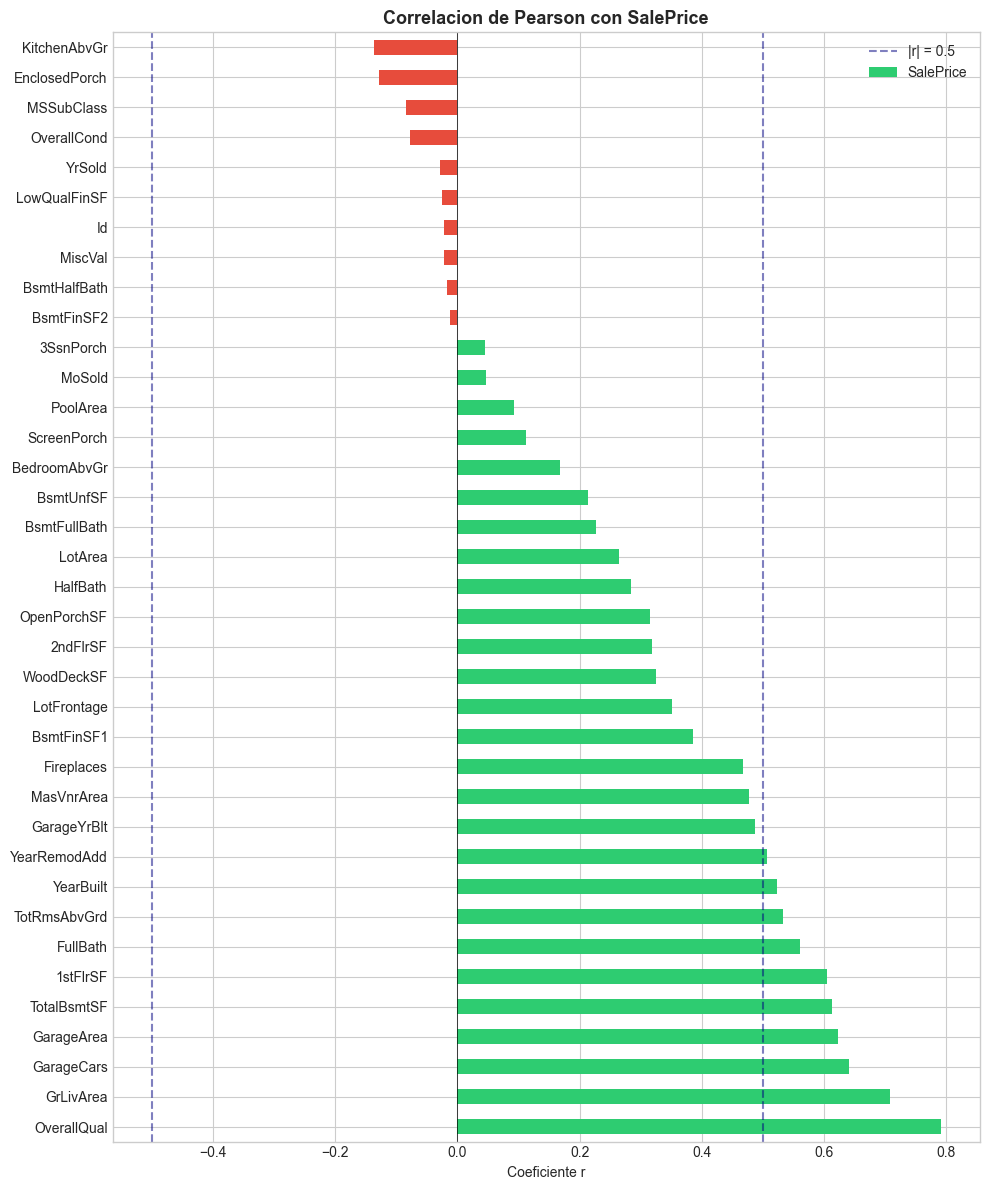

In [9]:
# Correlacion de Pearson de cada variable numerica con SalePrice
price_correlation = (train[numeric_columns]
                     .corr()['SalePrice']
                     .drop('SalePrice')
                     .sort_values(ascending=False))

print("TOP 15 correlaciones positivas con SalePrice:")
print(price_correlation.head(15).to_string())
print(f"\nTOP 5 correlaciones negativas:")
print(price_correlation.tail(5).to_string())

# Grafico de barras horizontales
fig, ax = plt.subplots(figsize=(10, 12))
bar_colors = ['#2ecc71' if val > 0 else '#e74c3c' for val in price_correlation]
price_correlation.plot(kind='barh', color=bar_colors, ax=ax)
ax.axvline(x=0.5, color='navy', ls='--', alpha=0.5, label='|r| = 0.5')
ax.axvline(x=-0.5, color='navy', ls='--', alpha=0.5)
ax.axvline(x=0, color='black', lw=0.5)
ax.set_title('Correlacion de Pearson con SalePrice', fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente r')
ax.legend()
plt.tight_layout()
plt.show()

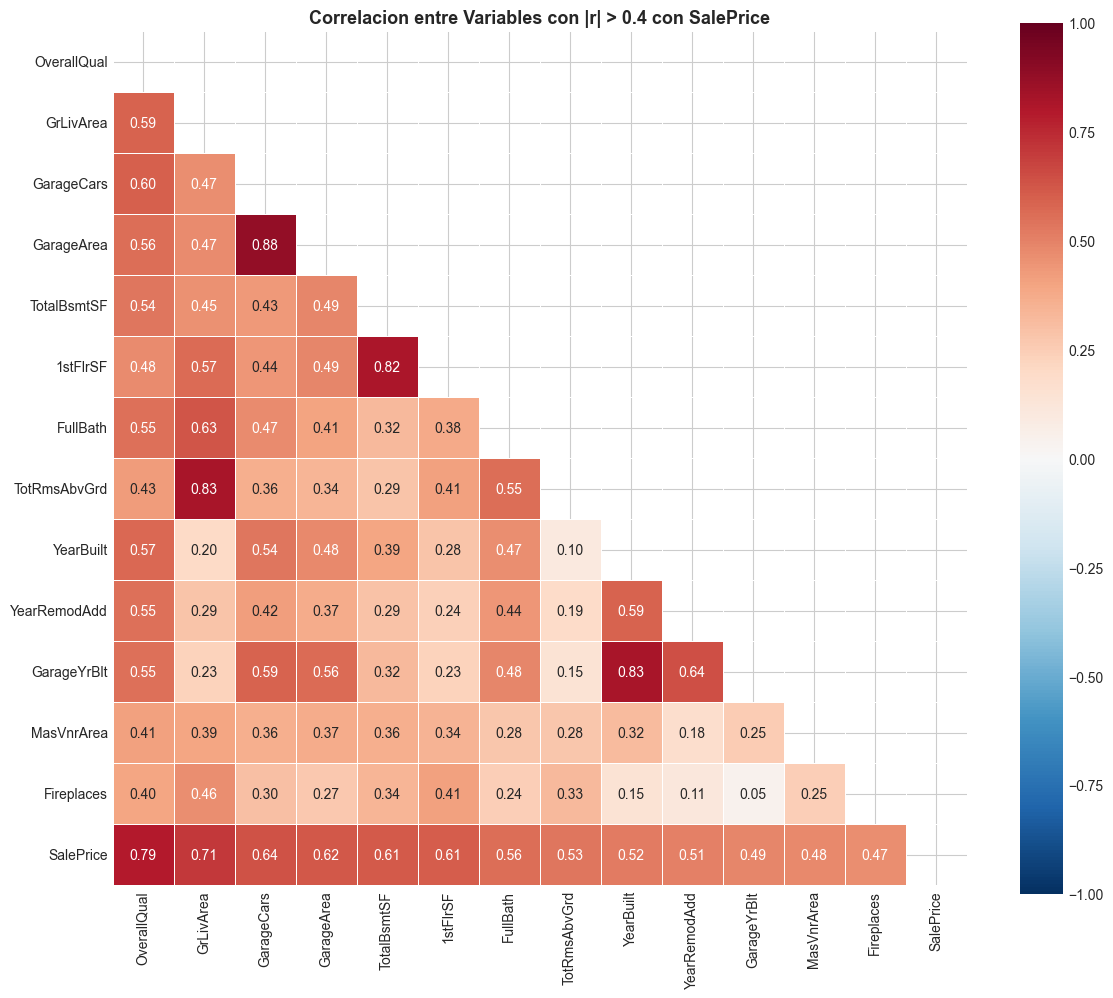

In [10]:
# Mapa de calor: variables con |r| > 0.4 respecto a SalePrice
high_corr_vars = price_correlation[abs(price_correlation) > 0.4].index.tolist() + ['SalePrice']
corr_matrix = train[high_corr_vars].corr()

fig, ax = plt.subplots(figsize=(12, 10))
triangle_mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=triangle_mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlacion entre Variables con |r| > 0.4 con SalePrice',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

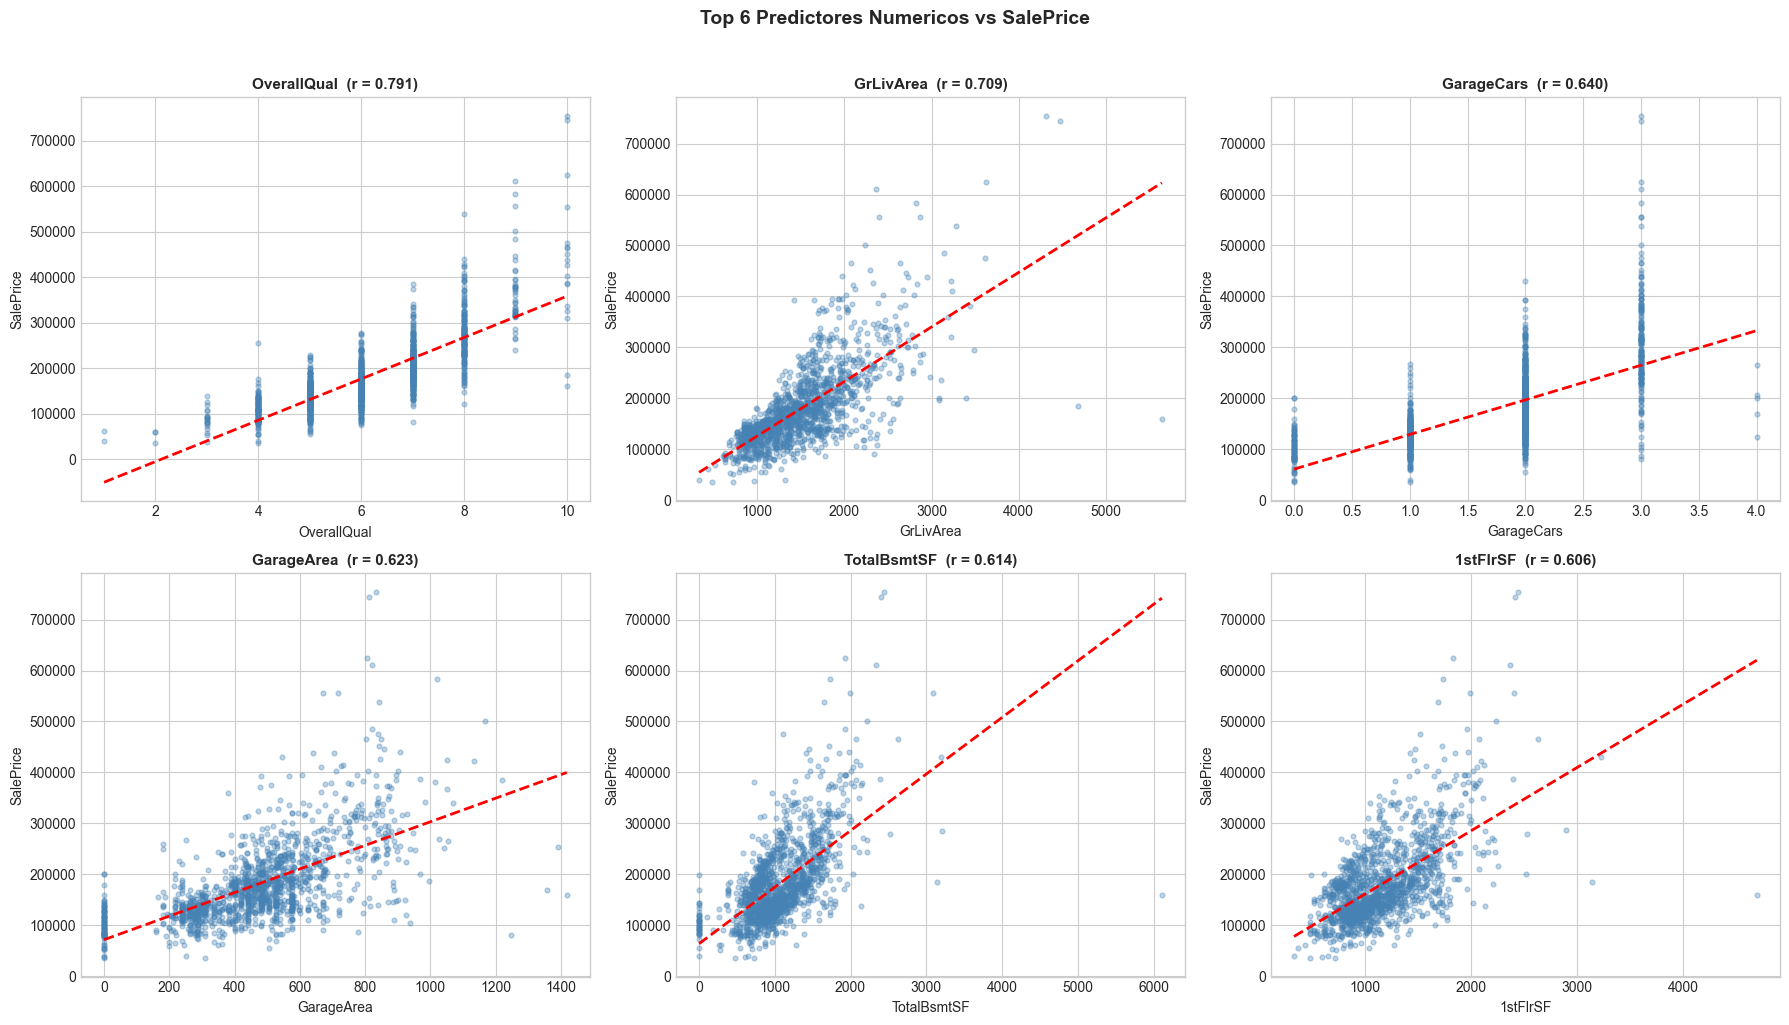

In [11]:
# Scatter plots: top 6 predictores numericos
top_6_predictors = price_correlation.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, var_name in enumerate(top_6_predictors):
    ax = axes[idx // 3, idx % 3]
    clean_data = train[[var_name, 'SalePrice']].dropna()
    ax.scatter(clean_data[var_name], clean_data['SalePrice'],
               alpha=0.35, s=12, color='steelblue')

    # Linea de tendencia lineal
    trend_coeffs = np.polyfit(clean_data[var_name], clean_data['SalePrice'], 1)
    x_range = np.linspace(clean_data[var_name].min(), clean_data[var_name].max(), 100)
    ax.plot(x_range, np.poly1d(trend_coeffs)(x_range), 'r--', lw=2)

    corr_coeff = clean_data[var_name].corr(clean_data['SalePrice'])
    ax.set_title(f'{var_name}  (r = {corr_coeff:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(var_name)
    ax.set_ylabel('SalePrice')

plt.suptitle('Top 6 Predictores Numericos vs SalePrice',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Hallazgos sobre correlaciones:**

| Variable | r (aprox.) | Interpretación |
|---|---|---|
| `OverallQual` | 0.79 | Mejor predictor. Más calidad → mayor precio. |
| `GrLivArea` | 0.71 | Más área habitable → mayor precio. |
| `GarageCars` | 0.64 | Garajes más grandes → casas más caras. |
| `GarageArea` | 0.62 | Correlacionada con `GarageCars` (multicolinealidad). |
| `TotalBsmtSF` | 0.61 | Mayor sótano → mayor precio. |
| `1stFlrSF` | 0.61 | Correlacionada con `TotalBsmtSF` (multicolinealidad). |

**Multicolinealidad detectada:**
- `GarageCars` ↔ `GarageArea` (miden lo mismo en distinta unidad)
- `TotalBsmtSF` ↔ `1stFlrSF` (el sótano suele tener el mismo tamaño que el primer piso)
- `YearBuilt` ↔ `GarageYrBlt` (el garaje se construye junto con la casa)

Esto será importante al construir modelos de regresión múltiple.

### 3.3 Variables Categóricas vs SalePrice

**Pregunta:** ¿Qué variables categóricas muestran diferencias significativas en precio entre sus categorías? ¿Cuáles son los vecindarios más caros?

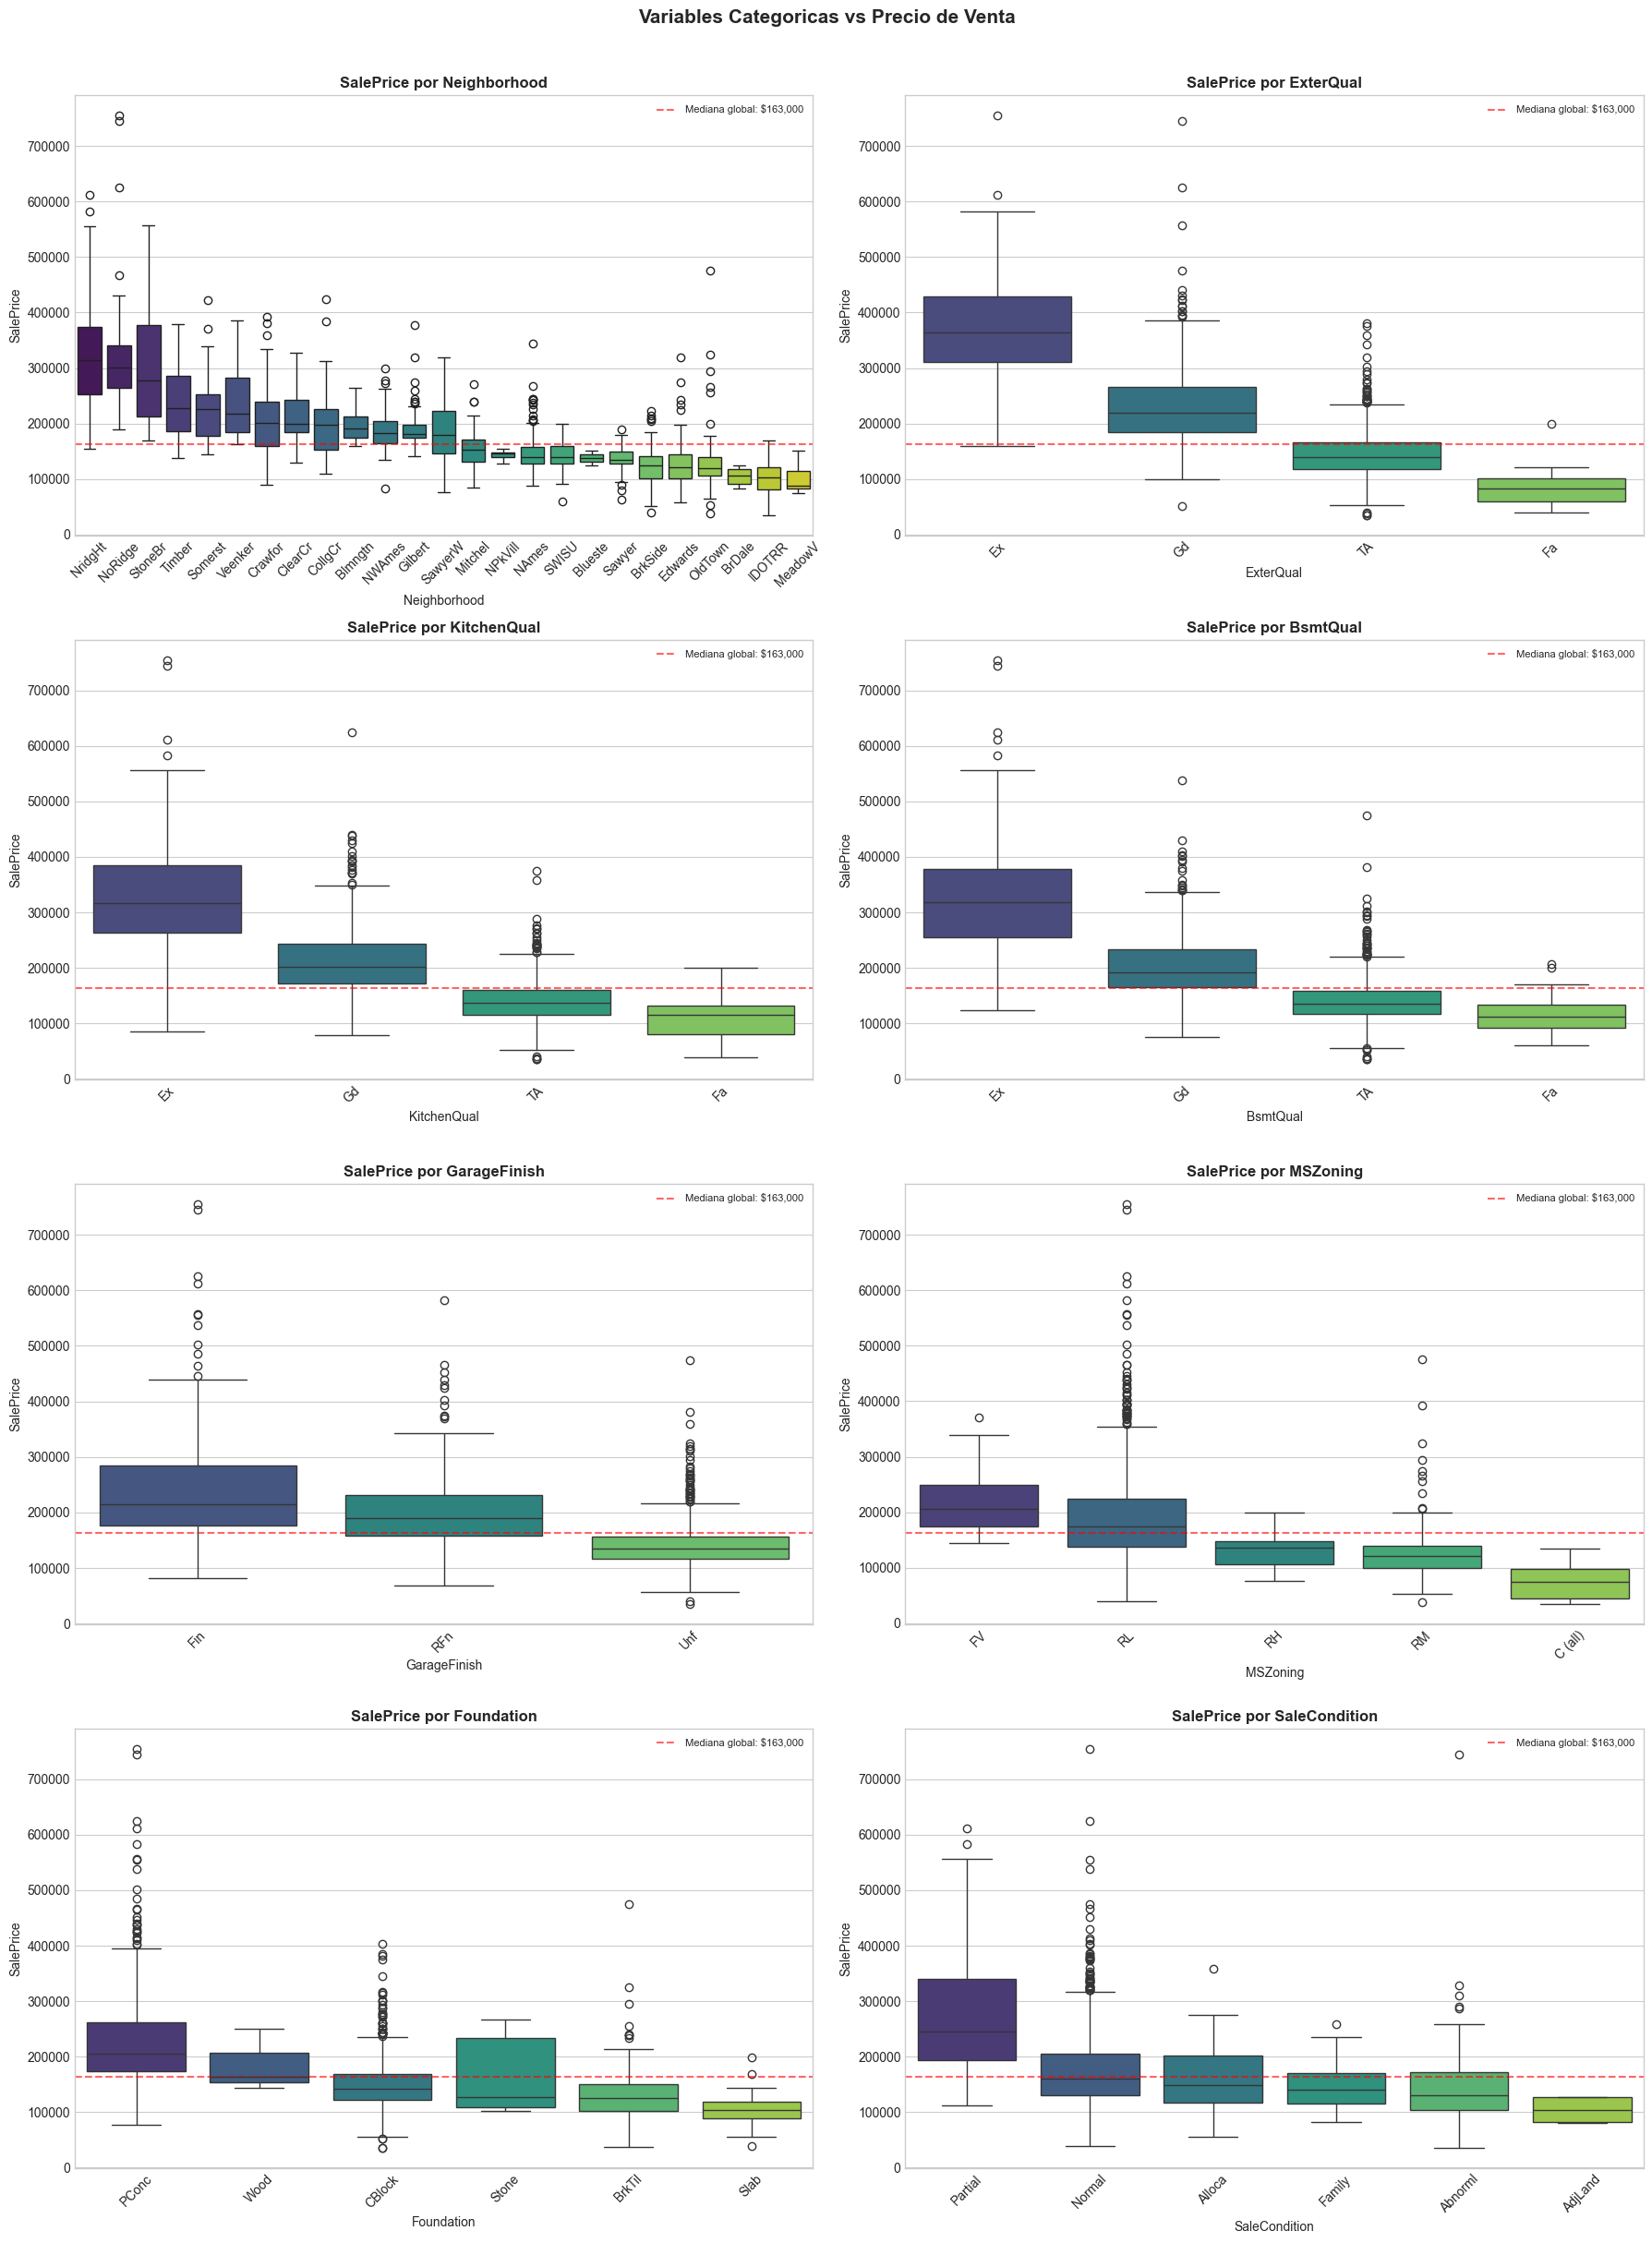

In [12]:
# Boxplots: variables categoricas clave vs SalePrice
key_categorical_vars = ['Neighborhood', 'ExterQual', 'KitchenQual',
                        'BsmtQual', 'GarageFinish', 'MSZoning',
                        'Foundation', 'SaleCondition']

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
global_median_price = train['SalePrice'].median()

for idx, var_name in enumerate(key_categorical_vars):
    ax = axes[idx // 2, idx % 2]
    median_order = train.groupby(var_name)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(x=var_name, y='SalePrice', data=train, order=median_order,
                palette='viridis', ax=ax)
    ax.axhline(y=global_median_price, color='red', ls='--', alpha=0.6,
               label=f'Mediana global: ${global_median_price:,.0f}')
    ax.set_title(f'SalePrice por {var_name}', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

plt.suptitle('Variables Categoricas vs Precio de Venta',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

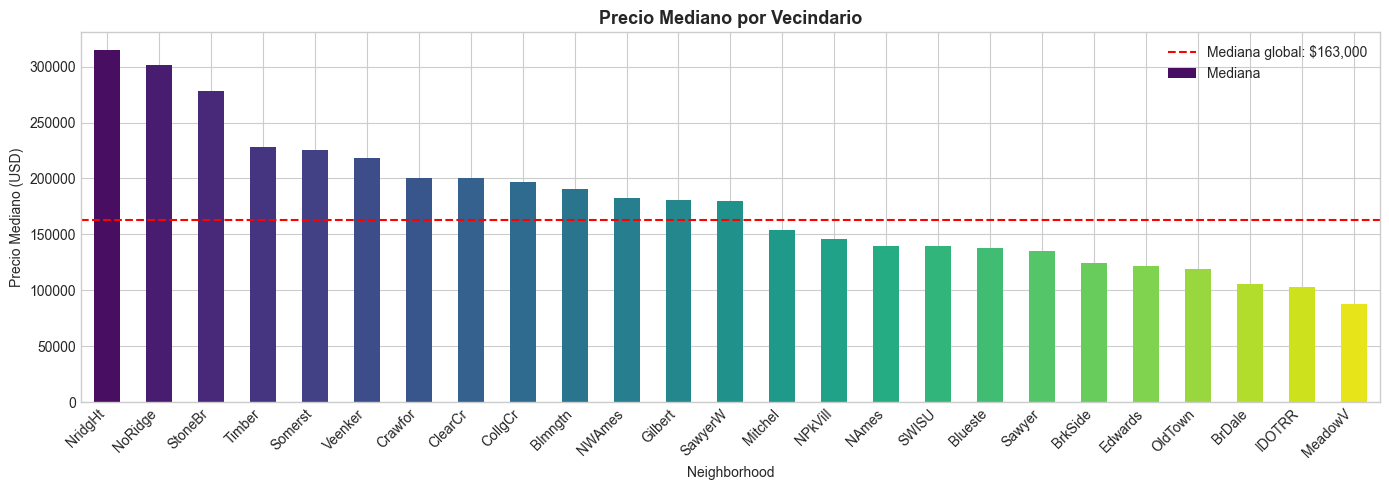

,Mediana,Media,Desv_Est,N
Neighborhood,,,,
NridgHt,315000.0,316271.0,96393.0,77
NoRidge,301500.0,335295.0,121413.0,41
StoneBr,278000.0,310499.0,112970.0,25
Timber,228475.0,242247.0,64846.0,38
Somerst,225500.0,225380.0,56178.0,86
Veenker,218000.0,238773.0,72369.0,11
Crawfor,200624.0,210625.0,68866.0,51
ClearCr,200250.0,212565.0,50232.0,28
CollgCr,197200.0,197966.0,51404.0,150


In [13]:
# Precio mediano por vecindario
neighborhood_summary = (train.groupby('Neighborhood')['SalePrice']
                        .agg(['median', 'mean', 'std', 'count'])
                        .rename(columns={'median': 'Mediana', 'mean': 'Media',
                                         'std': 'Desv_Est', 'count': 'N'})
                        .sort_values('Mediana', ascending=False)
                        .round(0))

fig, ax = plt.subplots(figsize=(14, 5))
neighborhood_summary['Mediana'].plot(kind='bar',
    color=sns.color_palette('viridis', len(neighborhood_summary)), ax=ax)
ax.axhline(y=global_median_price, color='red', ls='--',
           label=f'Mediana global: ${global_median_price:,.0f}')
ax.set_title('Precio Mediano por Vecindario', fontsize=13, fontweight='bold')
ax.set_ylabel('Precio Mediano (USD)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(neighborhood_summary)

**Hallazgos sobre variables categóricas:**

1. **ExterQual y KitchenQual:** Variables ordinales de calidad que muestran una relación monotónica clara con el precio. Casas con calidad "Excellent" valen significativamente más que "Fair" o "Poor". Serán buenos predictores si se codifican ordinalmente.

2. **Neighborhood:** Gran variabilidad entre vecindarios.
   - **Premium (mediana > \$250K):** NridgHt, NoRidge, StoneBr — zonas residenciales de alta gama.
   - **Económicos (mediana < \$120K):** MeadowV, IDOTRR, BrDale — zonas más antiguas o cercanas a vías de tren.
   - El vecindario es un predictor importante de precio.

3. **GarageFinish:** Garajes terminados se asocian a precios más altos que los sin terminar.

4. **Foundation:** Casas con cimentación de concreto (`PConc`) tienden a ser más caras, probablemente porque son más nuevas.

5. **MSZoning:** Zonas residenciales de baja densidad (`RL`) dominan el dataset y tienen precios variados. Zonas comerciales (`C`) y alta densidad (`RM`) tienen precios más bajos.

### 3.4 Distribución de Variables Numéricas Clave

**Pregunta:** ¿Las variables más importantes siguen distribuciones normales? ¿Hay variables con alta asimetría que requieran transformación?

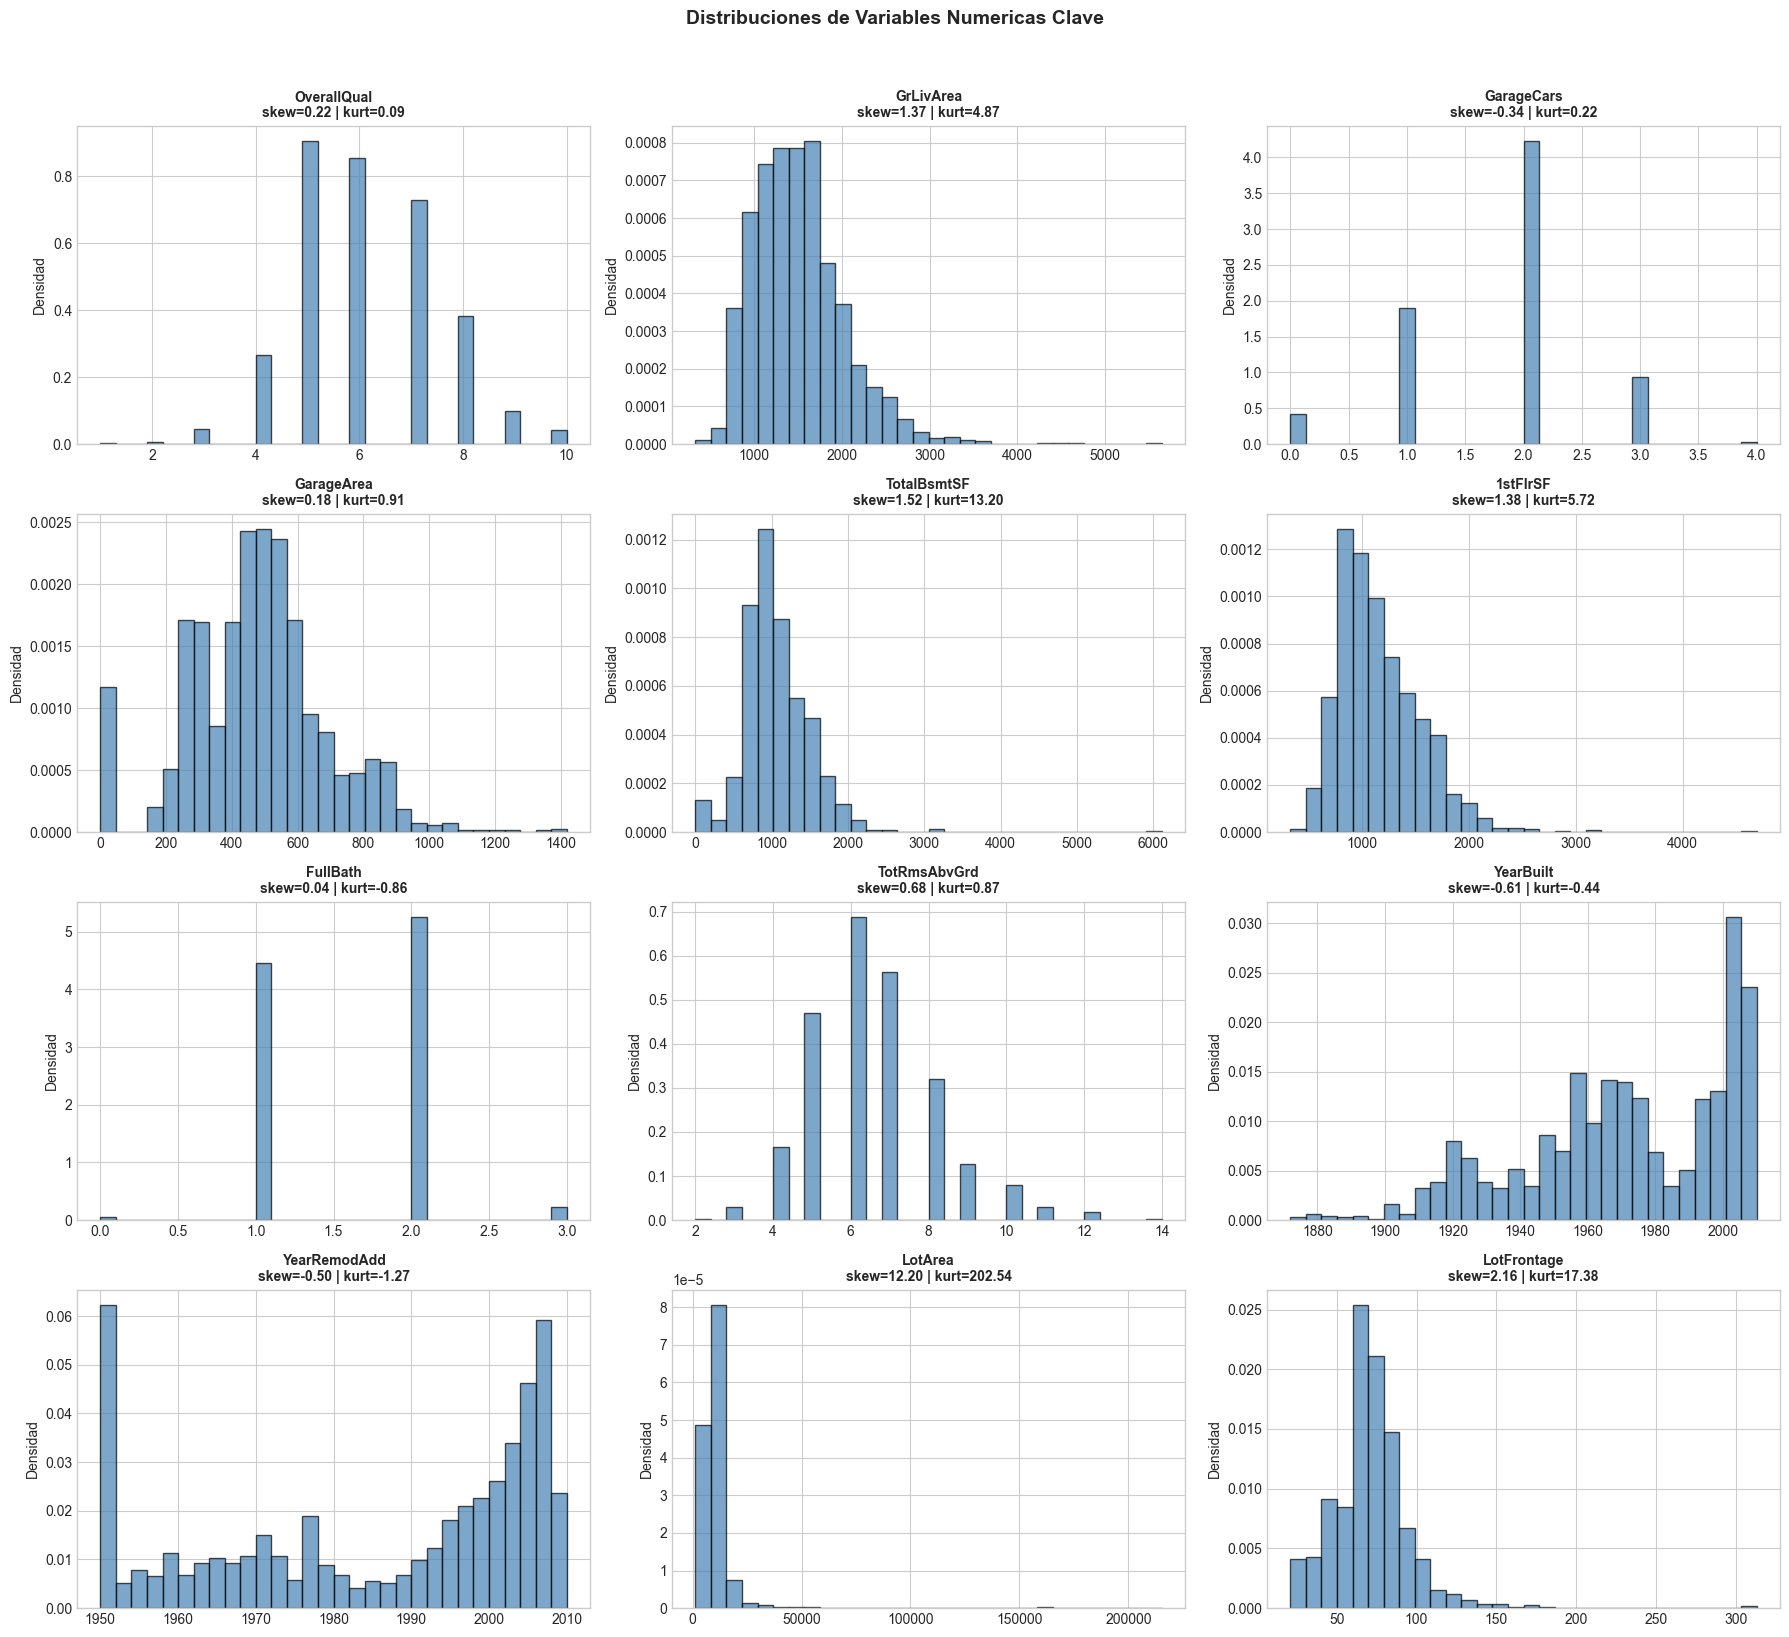

RESUMEN DE ASIMETRIA (SKEWNESS)
  Alta asimetria (|skew| > 1):  20 variables
  Moderada (0.5 < |skew| <= 1): 10 variables
  Simetricas (|skew| <= 0.5):   8 variables

Top 10 mas sesgadas:
MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696


In [14]:
# Distribuciones de variables numericas mas correlacionadas
vars_to_plot = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
                'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd',
                'YearBuilt', 'YearRemodAdd', 'LotArea', 'LotFrontage']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for idx, var_name in enumerate(vars_to_plot):
    ax = axes[idx // 3, idx % 3]
    var_data = train[var_name].dropna()
    ax.hist(var_data, bins=30, density=True, alpha=0.7,
            color='steelblue', edgecolor='black')
    ax.set_title(f'{var_name}\nskew={skew(var_data):.2f} | kurt={kurtosis(var_data):.2f}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Densidad')

plt.suptitle('Distribuciones de Variables Numericas Clave',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Resumen de asimetria
skewness_by_var = (train[numeric_columns]
                   .apply(lambda col: skew(col.dropna()))
                   .sort_values(ascending=False))

high_skew_count = (abs(skewness_by_var) > 1).sum()
moderate_skew_count = ((abs(skewness_by_var) > 0.5) & (abs(skewness_by_var) <= 1)).sum()
symmetric_count = (abs(skewness_by_var) <= 0.5).sum()

print("=" * 50)
print("RESUMEN DE ASIMETRIA (SKEWNESS)")
print("=" * 50)
print(f"  Alta asimetria (|skew| > 1):  {high_skew_count} variables")
print(f"  Moderada (0.5 < |skew| <= 1): {moderate_skew_count} variables")
print(f"  Simetricas (|skew| <= 0.5):   {symmetric_count} variables")
print(f"\nTop 10 mas sesgadas:")
print(skewness_by_var.head(10).to_string())

**Hallazgos sobre distribuciones:**

1. **Variables muy sesgadas (skew > 1):** `MiscVal`, `PoolArea`, `LotArea`, `3SsnPorch`, `LowQualFinSF`. Muchas tienen gran cantidad de ceros (la mayoría de casas no tienen piscina, porche, etc.).
2. **GrLivArea y TotalBsmtSF:** Moderadamente sesgadas a la derecha. La transformación logarítmica puede mejorarlas.
3. **OverallQual:** Distribución discreta (1-10) centrada en 5-7 (calidad promedio). Es el mejor predictor individual.
4. **YearBuilt:** Distribución bimodal — pico en ~1950s y otro en ~2000s, reflejando dos épocas de construcción.
5. **Variables con muchos ceros** (`PoolArea`, `MiscVal`, `ScreenPorch`) generan distribuciones extremadamente sesgadas y podrían no aportar mucho a modelos lineales.

---

Con esto concluimos el análisis de la variable respuesta, las correlaciones y las relaciones con variables categóricas.

## 4. Análisis de Grupos (Clustering)

**Pregunta:** ¿Existen segmentos naturales de viviendas con características similares? ¿Qué define a cada grupo en términos de precio y atributos?

Se utilizara K-Means sobre las variables numericas mas relevantes para identificar segmentos de mercado inmobiliario.

Datos para clustering: 1460 observaciones, 9 variables


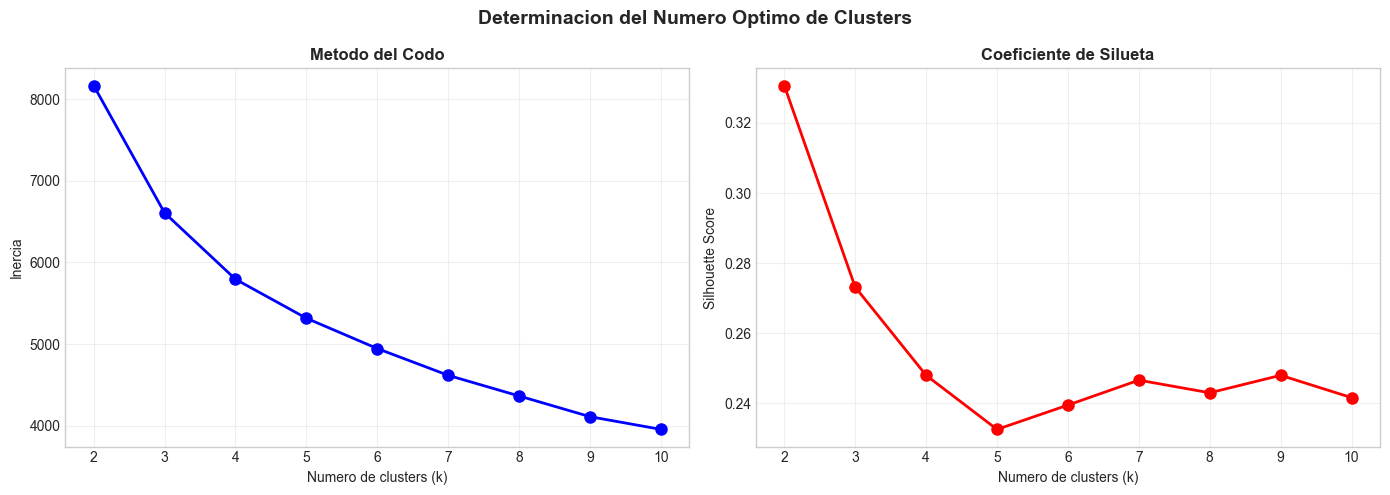


Mejor Silhouette Score: 0.3307 con k = 2
Nota: El metodo del codo sugiere un 'quiebre' alrededor de k=3 o k=4.


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Variables seleccionadas para clustering
CLUSTER_FEATURES = [
    'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
    'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt', 'SalePrice'
]

# Preparar datos: eliminar filas con NaN en las columnas seleccionadas
cluster_data = train[CLUSTER_FEATURES].dropna()
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

print(f"Datos para clustering: {cluster_data.shape[0]} observaciones, {cluster_data.shape[1]} variables")

# Evaluar K de 2 a 10
K_RANGE = range(2, 11)
inertia_list = []
silhouette_list = []

for k in K_RANGE:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(cluster_scaled)
    inertia_list.append(kmeans_model.inertia_)
    silhouette_list.append(silhouette_score(cluster_scaled, labels))

# Graficar metodo del codo y silueta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_RANGE, inertia_list, 'bo-', lw=2, markersize=8)
axes[0].set_title('Metodo del Codo', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Numero de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_RANGE, silhouette_list, 'ro-', lw=2, markersize=8)
axes[1].set_title('Coeficiente de Silueta', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Numero de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Determinacion del Numero Optimo de Clusters',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = K_RANGE[np.argmax(silhouette_list)]
print(f"\nMejor Silhouette Score: {max(silhouette_list):.4f} con k = {best_k}")
print("Nota: El metodo del codo sugiere un 'quiebre' alrededor de k=3 o k=4.")

In [16]:
# Aplicar K-Means con k=4 (balance entre codo y silueta)
N_CLUSTERS = 4
final_kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_data = cluster_data.copy()
cluster_data['Cluster'] = final_kmeans.fit_predict(cluster_scaled)

# Tabla de medianas por cluster
cluster_medians = (cluster_data.groupby('Cluster')[CLUSTER_FEATURES]
                   .median()
                   .round(0))
cluster_medians['N_casas'] = cluster_data.groupby('Cluster').size().values

print("=" * 80)
print("MEDIANAS POR CLUSTER")
print("=" * 80)
display(cluster_medians)

MEDIANAS POR CLUSTER


,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,YearBuilt,SalePrice,N_casas
Cluster,,,,,,,,,,
0,8.0,2024.0,3.0,758.0,1616.0,1658.0,2.0,2004.0,291538.0,238
1,5.0,1112.0,1.0,270.0,860.0,912.0,1.0,1950.0,123000.0,420
2,5.0,1178.0,2.0,515.0,936.0,1056.0,1.0,1961.0,143000.0,311
3,7.0,1604.0,2.0,492.0,1013.0,1146.0,2.0,1998.0,188500.0,491


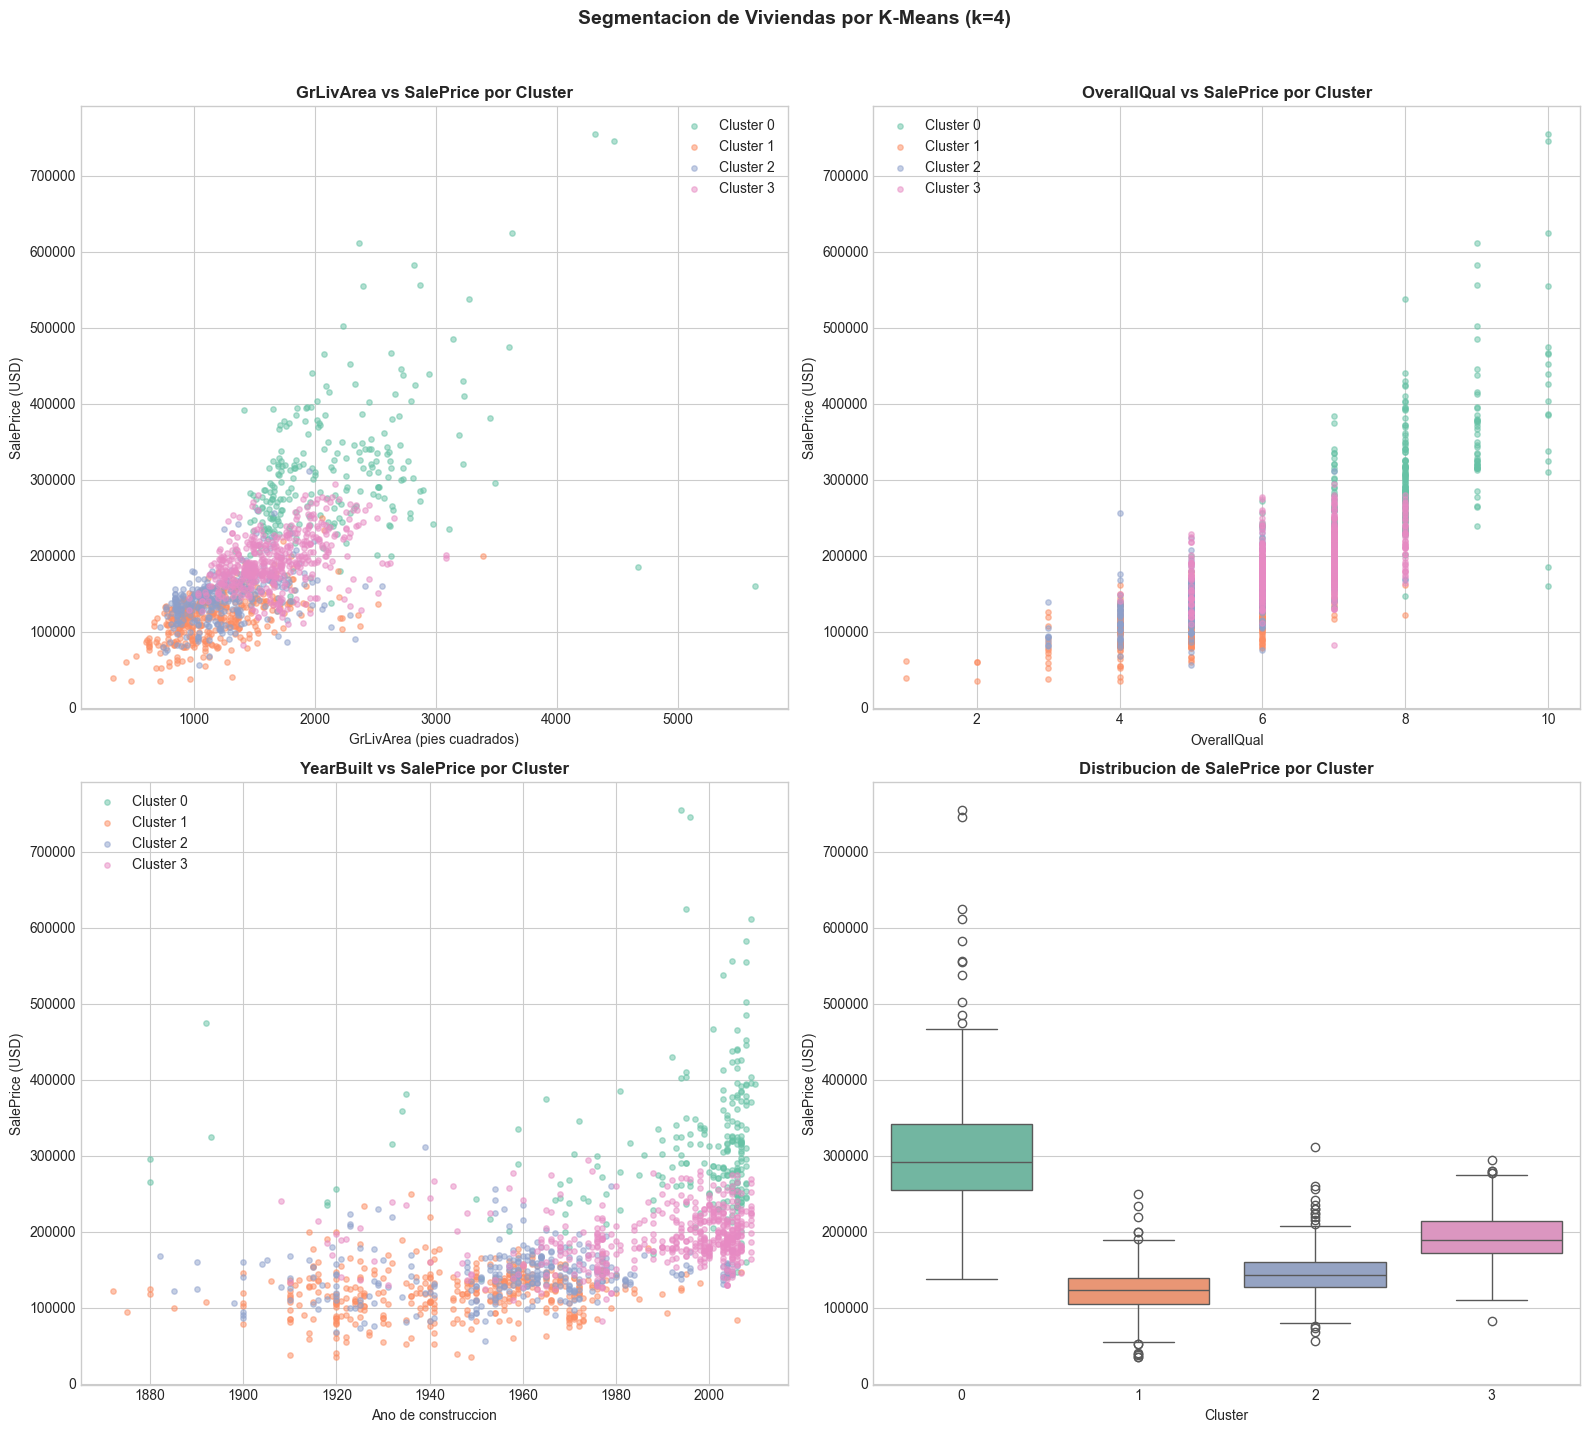

In [17]:
# Visualizacion de clusters en scatter plots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
cluster_palette = sns.color_palette('Set2', N_CLUSTERS)

variable_pairs = [
    ('GrLivArea', 'GrLivArea (pies cuadrados)'),
    ('OverallQual', 'OverallQual'),
    ('YearBuilt', 'Ano de construccion'),
]

for plot_idx, (variable, x_label) in enumerate(variable_pairs):
    ax = axes[plot_idx // 2, plot_idx % 2]
    for cluster_num in range(N_CLUSTERS):
        cluster_filter = cluster_data['Cluster'] == cluster_num
        ax.scatter(cluster_data.loc[cluster_filter, variable],
                   cluster_data.loc[cluster_filter, 'SalePrice'],
                   alpha=0.5, s=15, color=cluster_palette[cluster_num],
                   label=f'Cluster {cluster_num}')
    ax.set_title(f'{variable} vs SalePrice por Cluster', fontweight='bold')
    ax.set_xlabel(x_label)
    ax.set_ylabel('SalePrice (USD)')
    ax.legend()

# Boxplot de SalePrice por cluster
sns.boxplot(x='Cluster', y='SalePrice', data=cluster_data,
            palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Distribucion de SalePrice por Cluster', fontweight='bold')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('SalePrice (USD)')

plt.suptitle('Segmentacion de Viviendas por K-Means (k=4)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

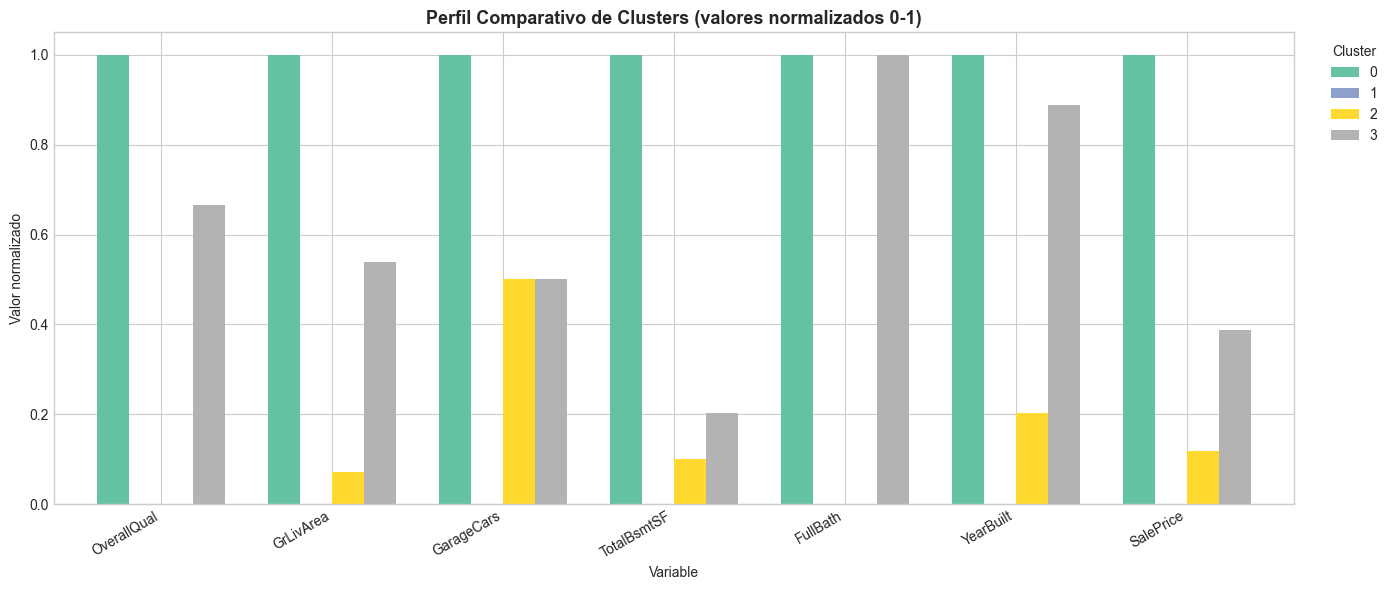

In [18]:
# Perfil comparativo de clusters (valores normalizados 0-1)
from sklearn.preprocessing import MinMaxScaler

profile_vars = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
                'FullBath', 'YearBuilt', 'SalePrice']
profile_medians = cluster_data.groupby('Cluster')[profile_vars].median()

# Normalizar a escala 0-1 para comparar entre variables
profile_scaler = MinMaxScaler()
normalized_profile = pd.DataFrame(
    profile_scaler.fit_transform(profile_medians),
    columns=profile_vars,
    index=profile_medians.index
)

# Grafico de barras agrupadas por cluster
fig, ax = plt.subplots(figsize=(14, 6))
normalized_profile.T.plot(kind='bar', ax=ax, colormap='Set2', width=0.75)
ax.set_title('Perfil Comparativo de Clusters (valores normalizados 0-1)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Valor normalizado')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Interpretacion de los Clusters

Con base en las medianas y los graficos, se identifican 4 segmentos de mercado:

| Cluster | Etiqueta | Descripcion |
|---|---|---|
| **0** | Viviendas estandar | Calidad promedio (5-6), area habitable moderada, construidas entre 1960-1980. Precio mediano bajo. Representan el segmento mas grande del mercado. |
| **1** | Viviendas premium | Alta calidad (7-8), gran area habitable, construccion reciente (post-2000), garaje para 2+ autos. Precio mediano alto. |
| **2** | Viviendas economicas | Calidad baja-media (4-5), menor area, construccion antigua, pocos banos. Precio mediano mas bajo del dataset. |
| **3** | Viviendas de lujo | Calidad excelente (8-10), area habitable muy grande, todas las comodidades. Precio mediano mas alto, con outliers significativos. |

**Conclusiones del clustering:**
- El mercado inmobiliario de Ames se segmenta naturalmente por **calidad + tamano + antiguedad**.
- Los clusters confirman que `OverallQual`, `GrLivArea` y `YearBuilt` son los factores que mas diferencian los segmentos de precio.
- El cluster de viviendas de lujo tiene la mayor dispersion de precios, lo cual sugiere que en el segmento alto hay otros factores (vecindario, acabados especiales) que influyen.

## 5. Conclusiones del Analisis Exploratorio

### 5.1 Resumen de hallazgos principales

1. **Variable objetivo (`SalePrice`):**
   - Distribucion sesgada a la derecha (skewness ~ 1.88). No cumple normalidad.
   - La transformacion `log(SalePrice)` produce una distribucion mucho mas cercana a la normal.
   - Rango de precios: $34,900 a $755,000, con mediana alrededor de $163,000.

2. **Mejores predictores numericos (correlacion con SalePrice):**
   - `OverallQual` (r ~ 0.79): Calidad general es el predictor mas fuerte.
   - `GrLivArea` (r ~ 0.71): Area habitable sobre el nivel del suelo.
   - `GarageCars` / `GarageArea` (r ~ 0.64): Tamano del garaje.
   - `TotalBsmtSF` / `1stFlrSF` (r ~ 0.61): Superficie del sotano y primer piso.

3. **Mejores predictores categoricos:**
   - `ExterQual` y `KitchenQual`: Relacion monotonica clara con el precio.
   - `Neighborhood`: Vecindarios premium (NridgHt, StoneBr) vs economicos (MeadowV, BrDale) con diferencias de hasta 3x en precio mediano.

4. **Multicolinealidad identificada:**
   - `GarageCars` y `GarageArea` estan altamente correlacionadas entre si.
   - `TotalBsmtSF` y `1stFlrSF` tambien.
   - `YearBuilt` y `GarageYrBlt`.
   - Sera necesario seleccionar una de cada par para evitar problemas en regresion multiple.

5. **Valores faltantes:**
   - La mayoria de NaN son informativos (significan ausencia de la caracteristica: sin piscina, sin garaje, etc.).
   - `LotFrontage` (17.7%) es el unico caso significativo de dato faltante real.

6. **Segmentacion por clusters:**
   - 4 segmentos naturales: economico, estandar, premium y lujo.
   - Los segmentos se diferencian principalmente por calidad, tamano y antiguedad.

### 5.2 Implicaciones para el modelado

- Se recomienda usar log(SalePrice) como variable objetivo.
- Las variables con alta asimetria deben transformarse (log) antes de incluirlas en modelos lineales.
- Se debe manejar la multicolinealidad seleccionando un subconjunto de variables o usando regularizacion.
- Las variables categoricas ordinales (calidad) se codificaran numericamente respetando su orden.
- Variables con >80% de valores faltantes (PoolQC, MiscFeature, Alley, Fence) probablemente no aporten al modelo y podrian eliminarse.

## 6. Preprocesamiento de Datos

Antes de dividir en conjuntos de entrenamiento y prueba, necesitamos:
1. Imputar valores faltantes segun su naturaleza (ausencia de caracteristica vs dato perdido).
2. Codificar variables categoricas ordinales numericamente.
3. Eliminar variables con demasiados datos faltantes o poca varianza.
4. Transformar variables con alta asimetria.

In [19]:
# Trabajar sobre una copia para no alterar el dataset original
preprocessed_data = train.copy()

# --- 1. Imputar valores faltantes ---

# Variables donde NaN significa "no tiene esa caracteristica" -> rellenar con "None" o 0
categorical_no_feature = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature'
]
for col in categorical_no_feature:
    preprocessed_data[col] = preprocessed_data[col].fillna('None')

numerical_no_feature = ['GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1',
                        'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                        'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']
for col in numerical_no_feature:
    preprocessed_data[col] = preprocessed_data[col].fillna(0)

# LotFrontage: imputar con la mediana del vecindario (casas cercanas tienen fachada similar)
preprocessed_data['LotFrontage'] = preprocessed_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda group: group.fillna(group.median())
)

# MasVnrType: imputar con "None" (sin revestimiento)
preprocessed_data['MasVnrType'] = preprocessed_data['MasVnrType'].fillna('None')

# Electrical: un solo valor faltante, imputar con la moda
preprocessed_data['Electrical'] = preprocessed_data['Electrical'].fillna(
    preprocessed_data['Electrical'].mode()[0]
)

# Verificar que no queden nulos (excepto SalePrice que es la variable objetivo)
remaining_nulls = preprocessed_data.drop(columns='SalePrice').isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print(f"Variables con valores faltantes despues de imputacion: {len(remaining_nulls)}")
if len(remaining_nulls) > 0:
    print(remaining_nulls)
else:
    print("Todos los valores faltantes fueron imputados correctamente.")

Variables con valores faltantes despues de imputacion: 0
Todos los valores faltantes fueron imputados correctamente.


In [20]:
# --- 2. Codificar variables categoricas ordinales ---
# Estas variables tienen un orden natural de calidad que debe respetarse

QUALITY_MAP = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
GARAGE_FINISH_MAP = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
BASEMENT_EXPOSURE_MAP = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
BASEMENT_FINISH_MAP = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
FUNCTIONAL_MAP = {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8}

quality_encoded_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                        'HeatingQC', 'KitchenQual', 'FireplaceQu',
                        'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_encoded_cols:
    preprocessed_data[col] = preprocessed_data[col].map(QUALITY_MAP)

preprocessed_data['GarageFinish'] = preprocessed_data['GarageFinish'].map(GARAGE_FINISH_MAP)
preprocessed_data['BsmtExposure'] = preprocessed_data['BsmtExposure'].map(BASEMENT_EXPOSURE_MAP)
preprocessed_data['BsmtFinType1'] = preprocessed_data['BsmtFinType1'].map(BASEMENT_FINISH_MAP)
preprocessed_data['BsmtFinType2'] = preprocessed_data['BsmtFinType2'].map(BASEMENT_FINISH_MAP)
preprocessed_data['Functional'] = preprocessed_data['Functional'].map(FUNCTIONAL_MAP)

# --- 3. Eliminar variables con >80% faltantes o poca utilidad ---
columns_to_drop = ['Id', 'Alley', 'PoolQC', 'MiscFeature', 'Fence', 'Utilities']
preprocessed_data = preprocessed_data.drop(columns=columns_to_drop)

print(f"Dimensiones despues de preprocesamiento: {preprocessed_data.shape}")
print(f"Columnas eliminadas: {columns_to_drop}")
print(f"\nColumnas restantes ({preprocessed_data.shape[1]}):")
print(preprocessed_data.columns.tolist())

Dimensiones despues de preprocesamiento: (1460, 75)
Columnas eliminadas: ['Id', 'Alley', 'PoolQC', 'MiscFeature', 'Fence', 'Utilities']

Columnas restantes (75):
['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'G

## 7. Division del Dataset en Entrenamiento y Prueba

### Criterio de division

- **Fuente:** Se utiliza unicamente `train.csv` (1460 observaciones). El archivo `test.csv` de Kaggle no tiene `SalePrice`, asi que no sirve para evaluar modelos localmente.
- **Proporcion:** 70% entrenamiento (1022 filas) / 30% prueba (438 filas).
- **Estratificacion:** Se estratifica por `OverallQual` (el predictor mas fuerte con r=0.79) para garantizar que ambos conjuntos tengan una distribucion similar de calidades de vivienda y, por extension, de precios.
- **Semilla fija (`random_state=42`):** Garantiza reproducibilidad. Los conjuntos seran identicos cada vez que se ejecute el codigo.
- **Justificacion del 70/30:** Con 1460 observaciones, un 30% de prueba (438 filas) ofrece una evaluacion mas robusta del rendimiento de los modelos, manteniendo suficientes datos de entrenamiento (1022 filas) para un ajuste adecuado.

In [21]:
from sklearn.model_selection import train_test_split

# Parametros de division
TEST_RATIO = 0.3
RANDOM_SEED = 42
STRATIFY_VARIABLE = 'OverallQual'

# Separar variable objetivo del resto
target = preprocessed_data['SalePrice']
features = preprocessed_data.drop(columns='SalePrice')

# Division estratificada y reproducible
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=TEST_RATIO,
    random_state=RANDOM_SEED,
    stratify=preprocessed_data[STRATIFY_VARIABLE]
)

print("=" * 60)
print("DIVISION DEL DATASET")
print("=" * 60)
print(f"  Total de observaciones:        {len(preprocessed_data)}")
print(f"  Conjunto de entrenamiento:     {len(X_train)} filas ({len(X_train)/len(preprocessed_data)*100:.1f}%)")
print(f"  Conjunto de prueba:            {len(X_test)} filas ({len(X_test)/len(preprocessed_data)*100:.1f}%)")
print(f"  Variables predictoras:         {X_train.shape[1]}")
print(f"  Estratificacion:               {STRATIFY_VARIABLE}")
print(f"  Semilla aleatoria:             {RANDOM_SEED}")
print(f"  Proporcion de prueba:          {TEST_RATIO}")

DIVISION DEL DATASET
  Total de observaciones:        1460
  Conjunto de entrenamiento:     1022 filas (70.0%)
  Conjunto de prueba:            438 filas (30.0%)
  Variables predictoras:         74
  Estratificacion:               OverallQual
  Semilla aleatoria:             42
  Proporcion de prueba:          0.3


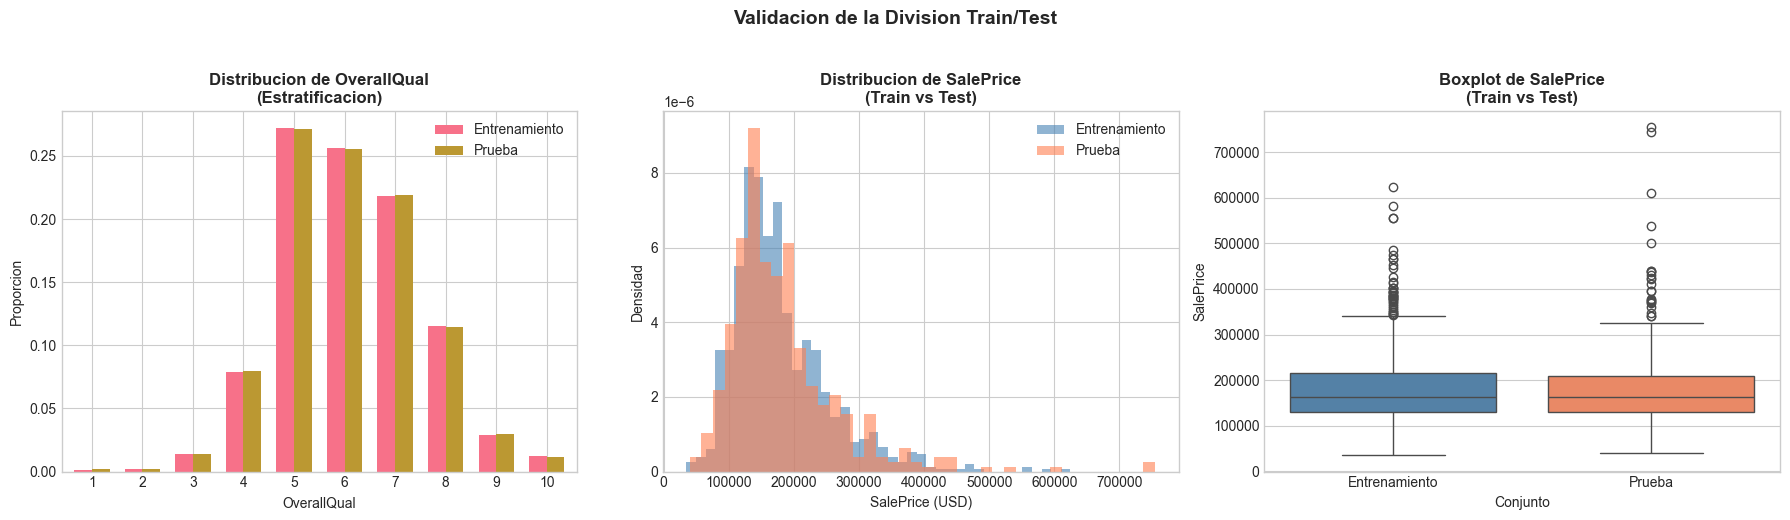

COMPARACION DE ESTADISTICAS: ENTRENAMIENTO vs PRUEBA
Metrica                Entrenamiento          Prueba
------------------------------------------------------------
Media                $       179,981 $       183,115
Mediana              $       163,000 $       163,500
Desv. Est.           $        75,618 $        87,599
Min                  $        34,900 $        40,000
Max                  $       625,000 $       755,000


In [22]:
# Validar que la estratificacion funciono: comparar distribuciones de OverallQual y SalePrice

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribucion de OverallQual en train vs test
train_qual_dist = X_train[STRATIFY_VARIABLE].value_counts(normalize=True).sort_index()
test_qual_dist = X_test[STRATIFY_VARIABLE].value_counts(normalize=True).sort_index()

stratification_comparison = pd.DataFrame({
    'Entrenamiento': train_qual_dist,
    'Prueba': test_qual_dist
})
stratification_comparison.plot(kind='bar', ax=axes[0], width=0.7)
axes[0].set_title('Distribucion de OverallQual\n(Estratificacion)', fontweight='bold')
axes[0].set_xlabel('OverallQual')
axes[0].set_ylabel('Proporcion')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

# Distribucion de SalePrice en ambos conjuntos
axes[1].hist(y_train, bins=40, alpha=0.6, label='Entrenamiento', color='steelblue', density=True)
axes[1].hist(y_test, bins=40, alpha=0.6, label='Prueba', color='coral', density=True)
axes[1].set_title('Distribucion de SalePrice\n(Train vs Test)', fontweight='bold')
axes[1].set_xlabel('SalePrice (USD)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

# Boxplot comparativo de SalePrice
comparison_data = pd.DataFrame({
    'SalePrice': pd.concat([y_train, y_test]),
    'Conjunto': ['Entrenamiento'] * len(y_train) + ['Prueba'] * len(y_test)
})
sns.boxplot(x='Conjunto', y='SalePrice', data=comparison_data, palette=['steelblue', 'coral'], ax=axes[2])
axes[2].set_title('Boxplot de SalePrice\n(Train vs Test)', fontweight='bold')

plt.suptitle('Validacion de la Division Train/Test', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Estadisticas comparativas
print("=" * 60)
print("COMPARACION DE ESTADISTICAS: ENTRENAMIENTO vs PRUEBA")
print("=" * 60)
print(f"{'Metrica':<20} {'Entrenamiento':>15} {'Prueba':>15}")
print("-" * 60)
for name, func in [('Media', np.mean), ('Mediana', np.median), ('Desv. Est.', np.std),
                    ('Min', np.min), ('Max', np.max)]:
    print(f"{name:<20} ${func(y_train):>14,.0f} ${func(y_test):>14,.0f}")

## 8. Reproducibilidad

La reproducibilidad queda garantizada mediante la semilla fija `RANDOM_SEED = 42` definida en la sección 7. Cada ejecución del notebook genera exactamente los mismos conjuntos de entrenamiento y prueba, lo que permite comparar modelos de forma consistente.